In [ ]:
!cp -r /content/drive/MyDrive/MoLe-VLA /content/MoLe-VLA
!cp -r /content/drive/MyDrive/CogACT-Base /content/CogACT-Base
!ln -s /content/MoLe-VLA /content/CogACT
print("Files restored!")

In [ ]:
!pip install transformers==4.40.1 tokenizers==0.19.1 accelerate==1.2.0 \
    peft==0.11.1 timm==0.9.10 sentencepiece==0.1.99 -q

In [ ]:
!pip install draccus einops json-numpy jsonlines wandb rich safetensors \
    huggingface-hub portalocker ptflops torchprofile tensorly trimesh \
    yacs tabulate scipy statsmodels -q

In [ ]:
!pip install tensorflow-datasets protobuf==5.29.4 -q

In [ ]:
!pip install git+https://github.com/moojink/dlimp_openvla --no-deps -q
!pip install git+https://github.com/arnoldland/openvla --no-deps -q

In [ ]:
!cp /content/drive/MyDrive/MoLe-VLA/llama2_patched.py \
    /usr/local/lib/python3.12/dist-packages/prismatic/models/backbones/llm/llama2.py
print("llama2 patch restored!")

In [ ]:
!huggingface-cli login

In [ ]:
import sys, os
from unittest.mock import MagicMock

# Paths
sys.path.insert(0, '/content/MoLe-VLA')
sys.path.insert(0, '/content/MoLe-VLA/vla')
sys.path.insert(0, '/content')
os.environ['PYTHONPATH'] = '/content/MoLe-VLA:/content/MoLe-VLA/vla'

# Mock tensorflow_graphics
_mock = MagicMock()
for m in ['tensorflow_graphics','tensorflow_graphics.geometry',
          'tensorflow_graphics.geometry.transformation']:
    sys.modules[m] = _mock

# Env vars — TRAIN_ROUTE=False for clean CogACT (no MoLE routing)
os.environ.update({
    'TRAIN_ROUTE': 'False',   # ← changed from True
    'MSE': '0.5', 'BALANCE': '0.1', 'KD': '0.5',
    'EMA_DECAY': '0.999', 'SKIP_LAYER_NUMBER': '14',
    'ADD_LSTM': 'False', 'FOR_ROUTE': 'False',
    'USE_INDEX': 'False', 'RANDOM_SEED': '32',
})

# Flash attn bypass
from transformers.modeling_utils import PreTrainedModel
def _bypass_flash(cls, config, **kw):
    config._attn_implementation = "sdpa"
    return config
PreTrainedModel._check_and_enable_flash_attn_2 = classmethod(_bypass_flash)

print("Setup complete!")

In [ ]:
from transformers import AutoModelForVision2Seq, AutoProcessor

processor = AutoProcessor.from_pretrained("openvla/openvla-7b", trust_remote_code=True)
model = AutoModelForVision2Seq.from_pretrained(
    "openvla/openvla-7b",
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
    trust_remote_code=True
).to("cuda")
model.eval()

processor_config.json:   0%|          | 0.00/130 [00:00<?, ?B/s]

processing_prismatic.py: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

configuration_prismatic.py: 0.00B [00:00, ?B/s]

modeling_prismatic.py: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/6.95G [00:00<?, ?B/s]

In [38]:
import torch.nn as nn

class SkipLayerWrapper(nn.Module):
    def __init__(self, layer):
        super().__init__()
        self.layer = layer
        self.skip = False

    def forward(self, hidden_states, *args, **kwargs):
        if self.skip:
            past_kv = kwargs.get('past_key_value', None)
            if past_kv is not None and hasattr(past_kv, 'key_cache'):
                past_kv.key_cache.append(None)
                past_kv.value_cache.append(None)
            outputs = (hidden_states,)
            if kwargs.get('output_attentions', False):
                outputs += (None,)
            if kwargs.get('use_cache', False):
                outputs += (None,)
            return outputs
        return self.layer(hidden_states, *args, **kwargs)

def wrap_layers(model):
    layers = model.language_model.model.layers
    for i in range(len(layers)):
        layer = layers[i]
        while hasattr(layer, 'layer') and hasattr(layer, 'skip'):
            layer = layer.layer  # peel off ALL wrapper levels
        layers[i] = SkipLayerWrapper(layer)
    print(f"Wrapped {len(layers)} layers cleanly")

def set_skip(model, skip_indices: list):
    layers = model.language_model.model.layers
    skip_set = set(skip_indices)
    for i, layer in enumerate(layers): layer.skip = (i in skip_set)

def reset_skip(model): set_skip(model, [])

NUM_LAYERS = 32
def skip_last_k(k):    return list(range(NUM_LAYERS - k, NUM_LAYERS))
def skip_first_k(k):   return list(range(k))
def skip_middle_k(k):  start = NUM_LAYERS//2 - k//2; return list(range(start, start+k))
def skip_alternate():  return list(range(1, NUM_LAYERS, 2))
def skip_random_k(k, seed=42):
    import random; random.seed(seed); return sorted(random.sample(range(NUM_LAYERS), k))

wrap_layers(model)
print("Strategies ready")

Wrapped 32 layers cleanly
Strategies ready


In [39]:
# Revert to fp32 — autocast can't handle PIL→tensor pipeline in bfloat16
model.vlm = model.vlm.to(torch.float32)
print("Model in fp32")

Model in fp32


In [40]:
import numpy as np
from PIL import Image
import torch

rng = np.random.RandomState(0)
test_image = Image.fromarray(rng.randint(0, 255, (224, 224, 3), dtype=np.uint8))
test_prompt = "In: What action should the robot take to move sponge near apple?\nOut:"

reset_skip(model)
torch.manual_seed(42)
inputs = processor(images=test_image, text=test_prompt, return_tensors="pt").to("cuda", torch.float32)
with torch.no_grad():
    a1 = model.predict_action(**inputs, unnorm_key="fractal20220817_data", do_sample=False)

set_skip(model, [])
torch.manual_seed(42)
with torch.no_grad():
    a2 = model.predict_action(**inputs, unnorm_key="fractal20220817_data", do_sample=False)

diff = np.abs(a1 - a2).max()
print(f"Max diff (should be ~0): {diff:.8f}")
print(f"Action shape: {a1.shape}")
assert diff < 1e-5, "FAILED — hook is broken!"
print("Baseline verification PASSED")

Max diff (should be ~0): 0.00000000
Action shape: (16, 7)
Baseline verification PASSED


In [41]:
# Smoke test: skipping layers should change output
set_skip(model, skip_last_k(8))
torch.manual_seed(42)
inputs = processor(images=test_image, text=test_prompt, return_tensors="pt").to("cuda", torch.float32)
with torch.no_grad():
    a_skip = model.predict_action(**inputs, unnorm_key="fractal20220817_data", do_sample=False)

reset_skip(model)
torch.manual_seed(42)
with torch.no_grad():
    a_base = model.predict_action(**inputs, unnorm_key="fractal20220817_data", do_sample=False)

diff = np.abs(a_skip - a_base).max()
print(f"Max diff with skip-last-8 (should be >0): {diff:.6f}")
assert diff > 1e-5, "FAILED — skip is not affecting output!"
print("Smoke test PASSED — ready for Day 3 benchmark")

Max diff with skip-last-8 (should be >0): 0.135203
Smoke test PASSED — ready for Day 3 benchmark


In [42]:
import time

set_skip(model, skip_last_k(8))
t0 = time.time()
inputs = processor(images=test_image, text=test_prompt, return_tensors="pt").to("cuda", torch.float32)
with torch.no_grad():
    a_skip = model.predict_action(**inputs, unnorm_key="fractal20220817_data", do_sample=False)
latency = time.time() - t0

mse = ((a_skip - a1) ** 2).mean().item()
print(f"skip-last-8  |  MSE vs baseline: {mse:.4f}  |  Latency: {latency*1000:.0f}ms")
reset_skip(model)
print("Reset done — Day 2 complete!")

skip-last-8  |  MSE vs baseline: 0.1570  |  Latency: 7367ms
Reset done — Day 2 complete!


In [44]:
import tensorflow_datasets as tfds
import tensorflow as tf
from PIL import Image
import numpy as np

print("Loading fractal data from GCS...")
ds = tfds.load(
    'fractal20220817_data',
    split='train',
    data_dir='gs://gresearch/robotics',
    shuffle_files=False
)

test_images, test_prompts, gt_actions = [], [], []

for episode in ds.take(5):
    for step in episode['steps'].take(10):
        obs = step['observation']
        img    = Image.fromarray(obs['image'].numpy())
        prompt = obs['natural_language_instruction'].numpy().decode('utf-8')
        act    = step['action']['world_vector'].numpy()
        test_images.append(img)
        test_prompts.append(prompt)
        gt_actions.append(act)
        if len(test_images) >= 50: break
    if len(test_images) >= 50: break

print(f"Loaded {len(test_images)} real frames")
print(f"Sample prompt: '{test_prompts[0]}'")
print(f"GT action shape: {gt_actions[0].shape}")

Loading fractal data from GCS...


06/12 [17:46:33] INFO     | >> Load dataset info from                                           ]8;id=800581;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/dataset_info.py\dataset_info.py]8;;\:]8;id=352944;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/dataset_info.py#711\711]8;;\
                          gs://gresearch/robotics/fractal20220817_data/0.1.0                                       

06/12 [17:46:34] INFO     | >> Load dataset info from                                           ]8;id=376417;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/dataset_info.py\dataset_info.py]8;;\:]8;id=888662;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/dataset_info.py#711\711]8;;\
                          gs://gresearch/robotics/fractal20220817_data/0.1.0                                       

06/12 [17:46:35] INFO     | >> Creating a tf.data.Dataset reading 1024 files located in folders:      ]8;id=481741;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/reader.py\reader.py]8;;\:]8;id=562275;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/reader.py#262\262]8;;\
                          gs://gresearch/robotics/fractal20220817_data/0.1.0.                                      

06/12 [17:46:36] INFO     | >> Constructing tf.data.Dataset fractal20220817_data for split     ]8;id=869693;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/logging/logging_logger.py\logging_logger.py]8;;\:]8;id=659176;file:///usr/local/lib/python3.12/dist-packages/tensorflow_datasets/core/logging/logging_logger.py#49\49]8;;\
                          train, from gs://gresearch/robotics/fractal20220817_data/0.1.0                           

Loaded 50 real frames
Sample prompt: 'pick rxbar chocolate from bottom drawer and place on counter'
GT action shape: (3,)


In [45]:
model.language_model.config.use_cache = False  # fix IndexError for non-last-k strategies

import time
import torch
import numpy as np

# ── benchmark config ──────────────────────────────────────────────────────────
N_IMAGES = len(test_images)
K_VALUES   = [4, 8, 12, 16]
STRATEGIES = {
    'baseline':      lambda k: [],
    'skip_last_k':   skip_last_k,
    'skip_first_k':  skip_first_k,
    'skip_middle_k': skip_middle_k,
    'skip_random_k': skip_random_k,
    'skip_alternate': lambda k: skip_alternate(),
}


# ── compute baseline actions (no skip) ───────────────────────────────────────
print("Computing baselines...")
baselines = []
for i, (img, prompt) in enumerate(zip(test_images, test_prompts)):
    vla_prompt = f"In: What action should the robot take to {prompt}?\nOut:"
    reset_skip(model)
    torch.manual_seed(42)
    inputs = processor(images=img, text=vla_prompt, return_tensors="pt").to("cuda", torch.float32)
    with torch.no_grad():
        a = model.predict_action(**inputs, unnorm_key="fractal20220817_data", do_sample=False)
    baselines.append(a)
print(f"Baselines done: {len(baselines)} actions, shape {baselines[0].shape}")

# ── benchmark loop ────────────────────────────────────────────────────────────
results = {}   # (strategy, k) -> {mse, latency_ms}

for strat_name, strat_fn in STRATEGIES.items():
    for k in ([0] if strat_name in ('baseline', 'skip_alternate') else K_VALUES):
        skip_idx = strat_fn(k)
        set_skip(model, skip_idx)
        n_skipped = len(skip_idx)

        mses, times = [], []
        for i, (img, prompt) in enumerate(zip(test_images, test_prompts)):
            vla_prompt = f"In: What action should the robot take to {prompt}?\nOut:"
            torch.manual_seed(42)
            inputs = processor(images=img, text=vla_prompt, return_tensors="pt").to("cuda", torch.float32)
            t0 = time.perf_counter()
            with torch.no_grad():
                a = model.predict_action(**inputs, unnorm_key="fractal20220817_data", do_sample=False)
            times.append((time.perf_counter() - t0) * 1000)
            mses.append(np.mean((a - baselines[i])**2))

        key = f"{strat_name}_k{k}" if strat_name not in ('baseline','skip_alternate') else strat_name
        results[key] = {
            'mse':        np.mean(mses),
            'latency_ms': np.mean(times[2:]),  # skip first 2 (warmup)
            'n_skipped':  n_skipped,
        }
        print(f"{key:30s}  skipped={n_skipped:2d}  MSE={np.mean(mses):.6f}  lat={np.mean(times[2:]):.1f}ms")

reset_skip(model)
print("\nBenchmark complete!")

Computing baselines...
Baselines done: 50 actions, shape (16, 7)
baseline                        skipped= 0  MSE=0.000000  lat=9166.9ms
skip_last_k_k4                  skipped= 4  MSE=0.003432  lat=8206.5ms
skip_last_k_k8                  skipped= 8  MSE=0.003821  lat=7303.1ms
skip_last_k_k12                 skipped=12  MSE=0.008638  lat=6362.9ms
skip_last_k_k16                 skipped=16  MSE=0.016312  lat=5440.7ms
skip_first_k_k4                 skipped= 4  MSE=0.061372  lat=8246.0ms
skip_first_k_k8                 skipped= 8  MSE=0.063348  lat=7277.8ms
skip_first_k_k12                skipped=12  MSE=0.064255  lat=6333.2ms
skip_first_k_k16                skipped=16  MSE=0.058549  lat=5416.7ms
skip_middle_k_k4                skipped= 4  MSE=0.005357  lat=8179.2ms
skip_middle_k_k8                skipped= 8  MSE=0.016102  lat=7250.0ms
skip_middle_k_k12               skipped=12  MSE=0.038240  lat=6317.1ms
skip_middle_k_k16               skipped=16  MSE=0.041798  lat=5412.5ms
skip_random_

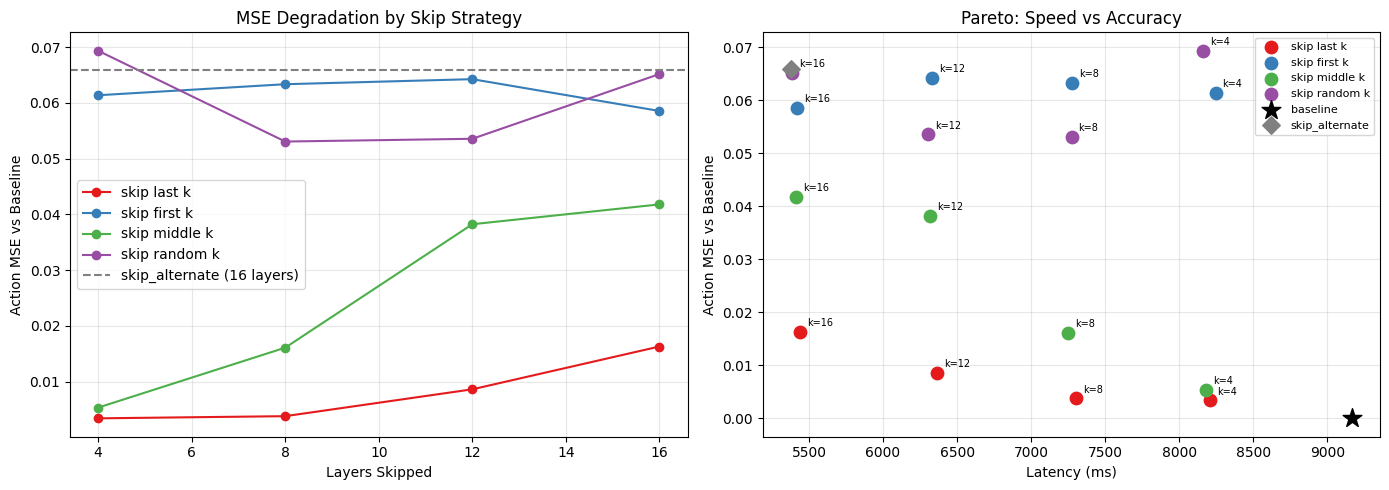

Saved benchmark_plots.png


In [46]:
import matplotlib.pyplot as plt

strategies = ['skip_last_k', 'skip_first_k', 'skip_middle_k', 'skip_random_k']
colors     = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: MSE vs layers skipped ────────────────────────────────────────────
ax = axes[0]
for strat, color in zip(strategies, colors):
    xs = [results[f'{strat}_k{k}']['n_skipped'] for k in K_VALUES]
    ys = [results[f'{strat}_k{k}']['mse']       for k in K_VALUES]
    ax.plot(xs, ys, marker='o', label=strat.replace('_',' '), color=color)

# skip_alternate as horizontal dashed line
alt = results['skip_alternate']
ax.axhline(alt['mse'], color='gray', linestyle='--', label=f"skip_alternate ({alt['n_skipped']} layers)")

ax.set_xlabel('Layers Skipped')
ax.set_ylabel('Action MSE vs Baseline')
ax.set_title('MSE Degradation by Skip Strategy')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot 2: Pareto — Latency vs MSE ─────────────────────────────────────────
ax = axes[1]
for strat, color in zip(strategies, colors):
    xs = [results[f'{strat}_k{k}']['latency_ms'] for k in K_VALUES]
    ys = [results[f'{strat}_k{k}']['mse']        for k in K_VALUES]
    ax.scatter(xs, ys, color=color, s=80, label=strat.replace('_',' '), zorder=3)
    for k, x, y in zip(K_VALUES, xs, ys):
        ax.annotate(f'k={k}', (x, y), textcoords='offset points', xytext=(5,4), fontsize=7)

# baseline point
ax.scatter(results['baseline']['latency_ms'], 0, marker='*', s=200, color='black', label='baseline', zorder=4)
ax.scatter(alt['latency_ms'], alt['mse'], marker='D', s=80, color='gray', label='skip_alternate', zorder=3)

ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Action MSE vs Baseline')
ax.set_title('Pareto: Speed vs Accuracy')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved benchmark_plots.png")

In [47]:
print(f"{'Config':<30} {'Skipped':>8} {'MSE':>12} {'Latency(ms)':>14} {'Speedup':>10}")
print("-" * 78)
base_lat = results['baseline']['latency_ms']
for key, v in sorted(results.items(), key=lambda x: x[1]['n_skipped']):
    speedup = base_lat / v['latency_ms']
    print(f"{key:<30} {v['n_skipped']:>8} {v['mse']:>12.6f} {v['latency_ms']:>14.1f} {speedup:>10.2f}x")

!cp benchmark_plots.png /content/drive/MyDrive/MoLe-VLA/
print("Plot saved to Drive")

Config                          Skipped          MSE    Latency(ms)    Speedup
------------------------------------------------------------------------------
baseline                              0     0.000000         9166.9       1.00x
skip_last_k_k4                        4     0.003432         8206.5       1.12x
skip_first_k_k4                       4     0.061372         8246.0       1.11x
skip_middle_k_k4                      4     0.005357         8179.2       1.12x
skip_random_k_k4                      4     0.069357         8164.1       1.12x
skip_last_k_k8                        8     0.003821         7303.1       1.26x
skip_first_k_k8                       8     0.063348         7277.8       1.26x
skip_middle_k_k8                      8     0.016102         7250.0       1.26x
skip_random_k_k8                      8     0.053070         7273.6       1.26x
skip_last_k_k12                      12     0.008638         6362.9       1.44x
skip_first_k_k12                     12   